# Voltametria Cíclica Irreversível — Mecanismo EC

Considera-se uma transferência de elétrons reversível seguida por uma reação química homogênea acoplada (mecanismo EC):

$$O + ne^- \rightleftharpoons R$$

$$R \rightleftharpoons P$$

Assumindo eletrodo planar e coeficientes de difusão iguais para $O$ e $R$, o transporte de massa é descrito pela segunda lei de Fick para cada espécie, com termos cinéticos para a reação química acoplada, para $0 \leq \tau \leq 2\tau_\lambda$ e $0 \leq y \leq 6\sqrt{D\tau_s}$:

$$\frac{\partial C_O}{\partial \tau} = D \frac{\partial^2 C_O}{\partial y^2}$$

$$\frac{\partial C_R}{\partial \tau} = D \frac{\partial^2 C_R}{\partial y^2} - k_f C_R + k_b C_P$$

$$\frac{\partial C_P}{\partial \tau} = D_P \frac{\partial^2 C_P}{\partial y^2} + k_f C_R - k_b C_P$$

As condições iniciais assumem $R$ e $P$ inicialmente ausentes:

$$C_O(y, 0) = C_O^* \qquad C_R(y, 0) = 0 \qquad C_P(y, 0) = 0$$

A difusão semi-infinita é aplicada no seio da solução:

$$\lim_{y \to \infty} C_O(y,\tau) = C_O^* \qquad \lim_{y \to \infty} C_R(y,\tau) = 0 \qquad \lim_{y \to \infty} C_P(y,\tau) = 0$$

O potencial varia ciclicamente com o tempo:

$$E(\tau) = E_i + v\tau, \quad \text{se} \quad \tau \leq \tau_\lambda$$

$$E(\tau) = E_f - v(\tau - \tau_\lambda), \quad \text{se} \quad \tau_\lambda \leq \tau \leq 2\tau_\lambda$$

O equilíbrio de Nernst é imposto na interface, com $\theta = \exp\!\left(\frac{F}{RT}(E - E^0)\right)$. A concentração superficial de $P$ é descontada da concentração total disponível:

$$C_O(0,\tau) = (C_O^* - C_P) \frac{\theta}{1+\theta} \quad \text{para} \quad \tau > 0$$

$$C_R(0,\tau) = (C_O^* - C_P) \frac{1}{1+\theta} \quad \text{para} \quad \tau > 0$$

$$N_P(0,\tau) = 0 \quad \text{para} \quad \tau > 0$$

Introduzindo as variáveis adimensionais, com $\tau_s = 1/fv$:

$$x = \frac{y}{\sqrt{D\tau_s}}, \quad t = \frac{\tau}{\tau_s}, \quad c_{O,R,P} = \frac{C_{O,R,P}}{C_O^*}, \quad \eta = f(E-E^0), \quad f = \frac{F}{RT}, \quad r = \frac{D_P}{D}$$

As constantes de velocidade adimensionais são definidas como:

$$K_f = k_f \tau_s, \qquad K_b = k_b \tau_s = \frac{K_f}{K_{eq}}$$

As equações tornam-se, para $t \geq 0$ e $0 \leq x \leq 6$:

$$\frac{\partial c_O}{\partial t} = \frac{\partial^2 c_O}{\partial x^2} \tag{1.0a}$$

$$\frac{\partial c_R}{\partial t} = \frac{\partial^2 c_R}{\partial x^2} - K_f c_R + K_b c_P \tag{1.0b}$$

$$\frac{\partial c_P}{\partial t} = r\frac{\partial^2 c_P}{\partial x^2} + K_f c_R - K_b c_P \tag{1.0c}$$

$$c_O(x, 0) = 1 \tag{1.1a}$$

$$c_R(x, 0) = 0 \tag{1.1b}$$

$$c_P(x, 0) = 0 \tag{1.1c}$$

$$\lim_{x \to \infty} c_O(x,t) = 1 \tag{1.2a}$$

$$\lim_{x \to \infty} c_R(x,t) = 0 \tag{1.2b}$$

$$\lim_{x \to \infty} c_P(x,t) = 0 \tag{1.2c}$$

com $\eta = \eta_i + t$ e $\theta = \exp(f\eta)$:

$$c_O(0,t) = (1 - c_P)\frac{\theta}{1+\theta} \tag{1.3a}$$

$$c_R(0,t) = (1 - c_P)\frac{1}{1+\theta} \tag{1.3b}$$

$$N_P(0,t) = 0 \tag{1.3c}$$

A densidade de corrente é proporcional ao fluxo difusional na superfície do eletrodo:

$$j(\tau) = nFD \left(\frac{\partial C_O}{\partial y}\right)_{y=0} = nFD\frac{C_O^*}{\sqrt{D\tau_s}} \left(\frac{\partial c_O}{\partial x}\right)_{x=0}$$

Definindo a corrente adimensional:

$$i(t) = \frac{j(\tau)\sqrt{D\tau_s}}{nFD C_O^*}$$

obtém-se:

$$i(t) = \left(\frac{\partial c_O}{\partial x}\right)_{x=0} \tag{3.0}$$

## Bibliotecas:

In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import Text, Button, HBox, VBox, Output
from IPython.display import display, clear_output

## Definindo o Modelo:

In [2]:
model = pybamm.BaseModel()

concentration_o = pybamm.Variable("Concentração de O", domain="electrolyte")
concentration_r = pybamm.Variable("Concentração de R", domain="electrolyte")
concentration_p = pybamm.Variable("Concentração de P", domain="electrolyte")

initial_potential      = pybamm.Parameter("Potencial Inicial [V]")
final_potential        = pybamm.Parameter("Potencial Final [V]")
standard_potential     = pybamm.Parameter("Potencial Padrão [V]")
scan_rate              = pybamm.Parameter("Velocidade de Varredura [V.s-1]")
faraday                = pybamm.Parameter("Constante de Faraday [C.mol-1]")
gas_constant           = pybamm.Parameter("Constante dos Gases [J.K-1.mol-1]")
temperature            = pybamm.Parameter("Temperatura [K]")
diffusion_ratio        = pybamm.Parameter("Razão de Difusão")
equilibrium_constant   = pybamm.Parameter("Constante de Equilíbrio")
forward_rate_constant  = pybamm.Parameter("Constante de Velocidade Direta")

backward_rate_constant = forward_rate_constant / equilibrium_constant  # kb = kf / K

flux_o = -pybamm.grad(concentration_o)   # fluxo difusional de O
flux_r = -pybamm.grad(concentration_r)   # fluxo difusional de R
flux_p = -pybamm.grad(concentration_p)   # fluxo difusional de P

model.rhs = {
    concentration_o: -pybamm.div(flux_o),                                                    # lei de Fick para O
    concentration_r: -pybamm.div(flux_r) - forward_rate_constant * concentration_r
                     + backward_rate_constant * concentration_p,                              # Fick + reação química para R
    concentration_p: -diffusion_ratio * pybamm.div(flux_p) + forward_rate_constant
                     * concentration_r - backward_rate_constant * concentration_p,            # Fick + reação química para P
}

# condições iniciais
model.initial_conditions = {
    concentration_o: pybamm.Scalar(1),  # c_O(x,0) = 1: O uniforme e adimensionalizado
    concentration_r: pybamm.Scalar(0),  # c_R(x,0) = 0: R inicialmente ausente
    concentration_p: pybamm.Scalar(0),  # c_P(x,0) = 0: P inicialmente ausente
}

# condições de contorno
# esquerda (x=0): interface eletrodo/solução — equilíbrio de Nernst, potencial varia ciclicamente
# direita  (x=6): seio da solução            — difusão semi-infinita
nernst_factor         = faraday / (gas_constant * temperature)           # f = F/(RT)
total_time            = 2 * (final_potential - initial_potential) / scan_rate
cosine                = pybamm.cos((np.pi / total_time) * pybamm.t)
sine                  = pybamm.sin((np.pi / total_time) * pybamm.t)
applied_potential     = initial_potential + (2 * (final_potential - initial_potential) / np.pi) * pybamm.AbsoluteValue(pybamm.arctan(sine / cosine))
overpotential         = applied_potential - standard_potential
theta                 = pybamm.exp(nernst_factor * overpotential)        # θ = exp(f·η)
surface_concentration_p = pybamm.boundary_value(concentration_p, "left")

model.boundary_conditions = {
    concentration_o: {
        "left":  ((1 - surface_concentration_p) * theta / (1 + theta), "Dirichlet"),  # equilíbrio de Nernst
        "right": (pybamm.Scalar(1),                                     "Dirichlet"),  # difusão semi-infinita
    },
    concentration_r: {
        "left":  ((1 - surface_concentration_p) / (1 + theta),         "Dirichlet"),  # equilíbrio de Nernst
        "right": (pybamm.Scalar(0),                                     "Dirichlet"),  # difusão semi-infinita
    },
    concentration_p: {
        "left":  (pybamm.Scalar(0),                                     "Neumann"),    # sem fluxo de P na superfície
        "right": (pybamm.Scalar(0),                                     "Dirichlet"),  # difusão semi-infinita
    },
}

model.variables = {
    "Concentração de O":  concentration_o,
    "Concentração de R":  concentration_r,
    "Concentração de P":  concentration_p,
    "Fluxo de O":         flux_o,
    "Fluxo de R":         flux_r,
    "Fluxo de P":         flux_p,
    "Potencial Aplicado": applied_potential,
}

param = pybamm.ParameterValues(
    {
        "Potencial Inicial [V]":              "[input]",
        "Potencial Final [V]":                "[input]",
        "Potencial Padrão [V]":               "[input]",
        "Velocidade de Varredura [V.s-1]":    "[input]",
        "Constante de Faraday [C.mol-1]":     96485.3,
        "Constante dos Gases [J.K-1.mol-1]":  8.31446,
        "Temperatura [K]":                    298.15,
        "Razão de Difusão":                   1,
        "Constante de Equilíbrio":            "[input]",
        "Constante de Velocidade Direta":     "[input]",
    }
)

## Geometria

In [3]:
# ── Geometria e Malha ─────────────────────────────────────────────────────────

x_variable = pybamm.SpatialVariable(
    "x", domain=["electrolyte"], coord_sys="cartesian"
)

geometry = {
    "electrolyte": {x_variable: {"min": pybamm.Scalar(0), "max": pybamm.Scalar(6)}}
}

## Malha

In [4]:
submesh_types = {
    "electrolyte": pybamm.MeshGenerator(
        pybamm.Exponential1DSubMesh,
        submesh_params={
            "side": "left",
            "stretch": 5,
        },
    )
}
variable_points = {x_variable: 400}
mesh            = pybamm.Mesh(geometry, submesh_types, variable_points)

## Discretização

In [5]:
# ── Discretização ─────────────────────────────────────────────────────────────

spatial_methods = {"electrolyte": pybamm.FiniteVolume()}
discretisation  = pybamm.Discretisation(mesh, spatial_methods)

param.process_model(model)
param.process_geometry(geometry)
discretisation.process_model(model)

## Solver

In [6]:
solver = pybamm.IDAKLUSolver()

## Gráfico Estático:

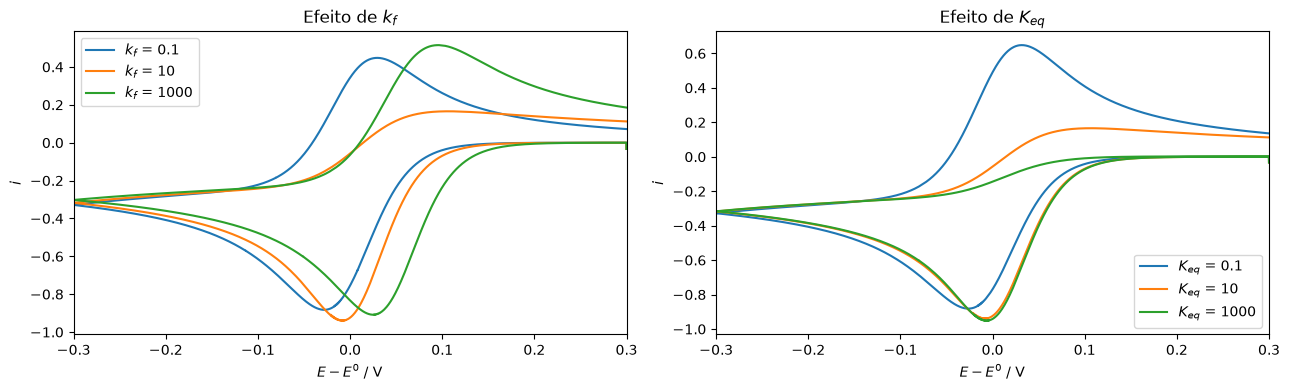

In [7]:
# potenciais fixos para a varredura cíclica
DEFAULT_INITIAL_POTENTIAL  =  0.3   # potencial inicial [V]
DEFAULT_FINAL_POTENTIAL    = -0.3   # potencial final [V]
DEFAULT_STANDARD_POTENTIAL =  0     # potencial padrão [V]
DEFAULT_SCAN_RATE          = -0.1   # velocidade de varredura [V/s]

final_time = 2 * (DEFAULT_FINAL_POTENTIAL - DEFAULT_INITIAL_POTENTIAL) / DEFAULT_SCAN_RATE
time       = np.linspace(0, final_time, 1000)

# ── variando a constante de equilíbrio ────────────────────────────────────────
equilibrium_constants = [0.1, 10, 1000]
DEFAULT_FORWARD_RATE  = 10

currents_equilibrium   = []
potentials_equilibrium = []

for equilibrium_constant_i in equilibrium_constants:
    solution = solver.solve(
        model, time,
        inputs={
            "Potencial Inicial [V]":           DEFAULT_INITIAL_POTENTIAL,
            "Potencial Final [V]":             DEFAULT_FINAL_POTENTIAL,
            "Potencial Padrão [V]":            DEFAULT_STANDARD_POTENTIAL,
            "Velocidade de Varredura [V.s-1]": DEFAULT_SCAN_RATE,
            "Constante de Equilíbrio":         equilibrium_constant_i,
            "Constante de Velocidade Direta":  DEFAULT_FORWARD_RATE,
        }
    )
    currents_equilibrium.append(solution["Fluxo de O"](solution.t, x=0))
    potentials_equilibrium.append(solution["Potencial Aplicado"](solution.t))

# ── variando a constante de velocidade direta ─────────────────────────────────
forward_rate_constants = [0.1, 10, 1000]
DEFAULT_EQUILIBRIUM    = 10

currents_forward   = []
potentials_forward = []

for forward_rate_constant_i in forward_rate_constants:
    solution = solver.solve(
        model, time,
        inputs={
            "Potencial Inicial [V]":           DEFAULT_INITIAL_POTENTIAL,
            "Potencial Final [V]":             DEFAULT_FINAL_POTENTIAL,
            "Potencial Padrão [V]":            DEFAULT_STANDARD_POTENTIAL,
            "Velocidade de Varredura [V.s-1]": DEFAULT_SCAN_RATE,
            "Constante de Equilíbrio":         DEFAULT_EQUILIBRIUM,
            "Constante de Velocidade Direta":  forward_rate_constant_i,
        }
    )
    currents_forward.append(solution["Fluxo de O"](solution.t, x=0))
    potentials_forward.append(solution["Potencial Aplicado"](solution.t))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for forward_rate_constant_i, current, potential in zip(forward_rate_constants, currents_forward, potentials_forward):
    ax1.plot(potential, current, label=r"$k_f$ = " + str(forward_rate_constant_i))

ax1.set_xlabel(r"$E - E^0$ / V")
ax1.set_ylabel(r"$i$")
ax1.set_xlim([DEFAULT_FINAL_POTENTIAL, DEFAULT_INITIAL_POTENTIAL])
ax1.set_title(r"Efeito de $k_f$")
ax1.legend(loc="upper left")

for equilibrium_constant_i, current, potential in zip(equilibrium_constants, currents_equilibrium, potentials_equilibrium):
    ax2.plot(potential, current, label=r"$K_{eq}$ = " + str(equilibrium_constant_i))

ax2.set_xlabel(r"$E - E^0$ / V")
ax2.set_ylabel(r"$i$")
ax2.set_xlim([DEFAULT_FINAL_POTENTIAL, DEFAULT_INITIAL_POTENTIAL])
ax2.set_title(r"Efeito de $K_{eq}$")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

O gráfico da esquerda mostra o efeito da constante de velocidade direta $k_f$ e, consequentemente, de $k_b$ no voltamograma cíclico, mantendo $K_{eq}=10$. Quando $k_f=0.1$ e $k_b=0.01$, o resultado se aproxima de um sistema reversível sem reação acoplada. Já quando $k_f$ apresenta um valor intermediário, a reação $R \rightleftharpoons P$ é mais rápida, consumindo $R$ mais rapidamente na solução. Isso reduz a concentração de $R$ disponível para reoxidação, diminuindo ou eliminando o pico anódico na varredura inversa. Quando $k_f=1000$ e, consequentemente, $k_b=100$, os potenciais de pico são deslocados e a corrente anódica volta a aumentar. Isto ocorre, pois o equilíbrio se reestabelece mais rapidamente, então conforme R é reoxidado, P rapidamente é convertido em R, impedindo seu esgotamento.

O gráfico da direita mostra o efeito da constante de equilíbrio $K_{eq}$. Valores altos de $K_{eq}$ favorecem termodinamicamente a formação de $P$, deslocando o potencial de pico para a direita e suprimindo o pico anódico. A comparação entre os dois gráficos permite distinguir efeitos cinéticos de efeitos termodinâmicos no voltamograma.

## Gráfico Interativo:

In [8]:
output = Output()

def plot(
    initial_potential_1_str, final_potential_1_str,
    standard_potential_1_str, scan_rate_1_str,
    equilibrium_constant_1_str, forward_rate_constant_1_str,
    initial_potential_2_str, final_potential_2_str,
    standard_potential_2_str, scan_rate_2_str,
    equilibrium_constant_2_str, forward_rate_constant_2_str,
):
    with output:
        clear_output(wait=True)

        # validação das entradas
        try:
            initial_potential_1     = float(initial_potential_1_str)
            final_potential_1       = float(final_potential_1_str)
            standard_potential_1    = float(standard_potential_1_str)
            scan_rate_1             = float(scan_rate_1_str)
            equilibrium_constant_1  = float(equilibrium_constant_1_str)
            forward_rate_constant_1 = float(forward_rate_constant_1_str)

            initial_potential_2     = float(initial_potential_2_str)
            final_potential_2       = float(final_potential_2_str)
            standard_potential_2    = float(standard_potential_2_str)
            scan_rate_2             = float(scan_rate_2_str)
            equilibrium_constant_2  = float(equilibrium_constant_2_str)
            forward_rate_constant_2 = float(forward_rate_constant_2_str)
        except ValueError:
            print("Por favor, insira valores numéricos válidos.")
            return

        if scan_rate_1 == 0 or scan_rate_2 == 0:
            print("A velocidade de varredura não pode ser zero.")
            return

        # constantes de velocidade reversa
        backward_rate_constant_1 = forward_rate_constant_1 / equilibrium_constant_1  # kb = kf / K
        backward_rate_constant_2 = forward_rate_constant_2 / equilibrium_constant_2

        # ── curva 1 ───────────────────────────────────────────────────────────
        final_time_1 = 2 * (final_potential_1 - initial_potential_1) / scan_rate_1
        solution_1   = solver.solve(
            model, np.linspace(0, final_time_1, 1000),
            inputs={
                "Potencial Inicial [V]":           initial_potential_1,
                "Potencial Final [V]":             final_potential_1,
                "Potencial Padrão [V]":            standard_potential_1,
                "Velocidade de Varredura [V.s-1]": scan_rate_1,
                "Constante de Equilíbrio":         equilibrium_constant_1,
                "Constante de Velocidade Direta":  forward_rate_constant_1,
            }
        )
        current_1   =  solution_1["Fluxo de O"](solution_1.t, x=0)
        potential_1 =  solution_1["Potencial Aplicado"](solution_1.t)

        # ── curva 2 ───────────────────────────────────────────────────────────
        final_time_2 = 2 * (final_potential_2 - initial_potential_2) / scan_rate_2
        solution_2   = solver.solve(
            model, np.linspace(0, final_time_2, 1000),
            inputs={
                "Potencial Inicial [V]":           initial_potential_2,
                "Potencial Final [V]":             final_potential_2,
                "Potencial Padrão [V]":            standard_potential_2,
                "Velocidade de Varredura [V.s-1]": scan_rate_2,
                "Constante de Equilíbrio":         equilibrium_constant_2,
                "Constante de Velocidade Direta":  forward_rate_constant_2,
            }
        )
        current_2   =  solution_2["Fluxo de O"](solution_2.t, x=0)
        potential_2 =  solution_2["Potencial Aplicado"](solution_2.t)

        # ── plotagem ──────────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(7, 4))

        ax.plot(potential_1, current_1, color="tab:blue", linewidth=1.5,
                label=f"Curva 1 ($K_{{eq}}$ = {equilibrium_constant_1}, $k_f$ = {forward_rate_constant_1}, $k_b$ = {backward_rate_constant_1:.4g})")
        ax.plot(potential_2, current_2, color="tab:red",  linewidth=1.5,
                label=f"Curva 2 ($K_{{eq}}$ = {equilibrium_constant_2}, $k_f$ = {forward_rate_constant_2}, $k_b$ = {backward_rate_constant_2:.4g})")

        ax.set_xlabel(r"$E$ / V")
        ax.set_ylabel(r"$i$")
        ax.set_xlim([min(final_potential_1, final_potential_2), max(initial_potential_1, initial_potential_2)])
        ax.set_title("Comparação de Voltamogramas — Mecanismo EC")
        ax.legend()

        plt.tight_layout()
        display(fig)
        plt.close(fig)


# ── Widgets — 1ª Varredura ────────────────────────────────────────────────────

field_initial_potential_1     = Text(value="0.5",   description="$E_{i,1}$ [V]:", style={"description_width": "initial"})
field_final_potential_1       = Text(value="-0.5",  description="$E_{f,1}$ [V]:", style={"description_width": "initial"})
field_standard_potential_1    = Text(value="0",     description="$E^0_1$ [V]:",   style={"description_width": "initial"})
field_scan_rate_1             = Text(value="-0.1",  description="$v_1$ [V/s]:",   style={"description_width": "initial"})
field_equilibrium_constant_1  = Text(value="0.001", description="$K_{eq,1}$:",    style={"description_width": "initial"})
field_forward_rate_constant_1 = Text(value="0.001", description="$k_{f,1}$:",     style={"description_width": "initial"})


# ── Widgets — 2ª Varredura ────────────────────────────────────────────────────

field_initial_potential_2     = Text(value="0.5",   description="$E_{i,2}$ [V]:", style={"description_width": "initial"})
field_final_potential_2       = Text(value="-0.5",  description="$E_{f,2}$ [V]:", style={"description_width": "initial"})
field_standard_potential_2    = Text(value="0",     description="$E^0_2$ [V]:",   style={"description_width": "initial"})
field_scan_rate_2             = Text(value="-0.1",  description="$v_2$ [V/s]:",   style={"description_width": "initial"})
field_equilibrium_constant_2  = Text(value="1000",  description="$K_{eq,2}$:",    style={"description_width": "initial"})
field_forward_rate_constant_2 = Text(value="1000",  description="$k_{f,2}$:",     style={"description_width": "initial"})

button = Button(description="Recalcular", button_style="success")

def on_click(b):
    plot(
        field_initial_potential_1.value,     field_final_potential_1.value,
        field_standard_potential_1.value,    field_scan_rate_1.value,
        field_equilibrium_constant_1.value,  field_forward_rate_constant_1.value,
        field_initial_potential_2.value,     field_final_potential_2.value,
        field_standard_potential_2.value,    field_scan_rate_2.value,
        field_equilibrium_constant_2.value,  field_forward_rate_constant_2.value,
    )

button.on_click(on_click)

interface = VBox([
    HBox([field_initial_potential_1, field_final_potential_1, field_standard_potential_1, field_scan_rate_1]),
    HBox([field_equilibrium_constant_1, field_forward_rate_constant_1]),
    HBox([field_initial_potential_2, field_final_potential_2, field_standard_potential_2, field_scan_rate_2]),
    HBox([field_equilibrium_constant_2, field_forward_rate_constant_2]),
    button,
    output,
])
display(interface)

# exibe o gráfico inicial com os valores padrão
plot(
    field_initial_potential_1.value,     field_final_potential_1.value,
    field_standard_potential_1.value,    field_scan_rate_1.value,
    field_equilibrium_constant_1.value,  field_forward_rate_constant_1.value,
    field_initial_potential_2.value,     field_final_potential_2.value,
    field_standard_potential_2.value,    field_scan_rate_2.value,
    field_equilibrium_constant_2.value,  field_forward_rate_constant_2.value,
)